In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch

## Load anno data

In [2]:
import sys
import os
import pandas as pd
import importlib

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    # load_cell_pixcoords,load_hist_embeddings
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_per_class_f1,
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
segment_data2 = 'NCRT_project - seg 15-28'
stardist_data = 'StarDist_Segment'
export_data = 'export'
save_result = 'result'

Successfully reloaded functions from base.py
openslide: True, tifffile: True


### Load GT

In [ ]:
celltype_level2_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv'
celltype_level1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv'
celltype_anno_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=True)
celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=False)
celltype_anno_df.head()

The number of cells: 10893249
[merge_celltype_level12] TumorID normalized: A_* / S_* -> SA_* before save
Celltype annotation DataFrame saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/codex_meta_celltype_final.csv
The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,SA_tumor2,Treg,CD4+T
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,SA_tumor2,Bn,B
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,SA_tumor2,B_other,B
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,SA_tumor2,B_other,B
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,SA_tumor2,B_other,B


In [ ]:
celltype_coords_df1 = pd.read_csv(f'{therapy_data}/{segment_data1}/{export_data}/{therapy_data}-measurements-tumor1-14.csv')
celltype_coords_df2 = pd.read_csv(f'{therapy_data}/{segment_data2}/{export_data}/{therapy_data}-measurements-tumor-15-28.csv')
celltype_coords_df = pd.concat([celltype_coords_df1, celltype_coords_df2], ignore_index=True)
print("Cell numbers of 1-14:", celltype_coords_df1.shape)
print("Cell numbers of 15-28:", celltype_coords_df2.shape)
print("Cell numbers of 1-28:", celltype_coords_df.shape)
celltype_coords_df.head()

Cell numbers of 1-14: (870924, 58)
Cell numbers of 15-28: (1021484, 58)
Cell numbers of 1-28: (1892408, 58)


,Image,Object ID,Name,Class,Parent,ROI,Centroid X µm,Centroid Y µm,Detection probability,Nucleus: Area µm^2,...,PD-1: Cell: Mean,CD14: Cell: Mean,CD27: Cell: Mean,CD123: Cell: Mean,Granzyme B: Cell: Mean,c-PARP: Nucleus: Mean,CD38: Cell: Mean,LAG3: Cell: Mean,TCF-1: Nucleus: Mean,PD-L1: Cell: Mean
0,NCRT PCF.qptiff - resolution #1,e071bc4e-01bc-4831-a466-25be5330e3df,PathCellObject,NaN,tumor1,Polygon,4159.0,1.242,0.5100,3.9411,...,198.2059,188.0294,13.0588,12.4118,0.0000,1.6875,0.0000,33.8529,144.6875,33.2647
1,NCRT PCF.qptiff - resolution #1,99103727-0736-484a-93b0-f83efe823c03,PathCellObject,NaN,tumor1,Polygon,3970.5,2.817,0.8954,12.8580,...,198.8849,902.8584,39.9646,61.3628,0.1947,42.9184,7.4248,91.5575,178.2857,102.2389
2,NCRT PCF.qptiff - resolution #1,4882bef1-7690-443b-8e2c-512d3e81c77b,PathCellObject,NaN,tumor1,Polygon,4027.5,2.793,0.8912,30.7944,...,151.2155,2110.7844,15.8190,24.5216,0.0000,12.0635,0.3405,82.9138,138.8651,39.8319
3,NCRT PCF.qptiff - resolution #1,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,PathCellObject,NaN,tumor1,Polygon,4172.1,3.086,0.8751,28.3653,...,41.6081,88.2297,58.7523,6.5405,0.0000,1.8509,0.1171,22.0045,35.0351,11.9595
4,NCRT PCF.qptiff - resolution #1,ff987357-f306-42ab-8e03-233ac4f5e850,PathCellObject,NaN,tumor1,Polygon,3996.6,3.635,0.6372,30.5691,...,79.1639,1005.8992,7.1471,5.0840,0.0000,1.4878,0.0000,85.4328,33.2439,17.2185


In [28]:
print("The number of ROIs", len(celltype_anno_df['TumorID'].unique()))
celltype_NCRT_tumor1 = celltype_anno_df[celltype_anno_df['TumorID'] == 'NCRT_tumor1']
print("The number of cells in NCRT_tumor1", celltype_NCRT_tumor1.shape[0])
celltype_NCRT_tumor1.head()

The number of ROIs 140
The number of cells in NCRT_tumor1 80303


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
4951957,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal
4951958,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid
4951959,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid
4951960,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal
4951961,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid


In [6]:
# ## extract and save cell type information for all TumorIDs
# saved_files_info = extract_and_save_celltype_by_tumorid(celltype_anno_df, base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/')

In [7]:
# ## Call the function to batch visualize all folders
# visualize_all_celltype_distributions(base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype')

The number of cells in celltype: 10365126
The distribution of celltype: celltype
CD8_Tpex                 1329760
Muscle&mCAF              1197496
CAF_other                 853404
Treg                      813448
Tumor_PDL1pos_MHCIpos     770217
Plasma                    738198
Endothelial               537909
Epithelial                496437
CD4_Tex                   418058
Monocyte                  385513
Macro_other               288451
Tumor_PDL1neg_MHCIpos     239810
Neutrophil                231752
CD8_Tex                   208595
Bm_unswitched             150591
Bm_switched               136771
Tumor_PDL1neg_MHCIneg     135267
Th17                      113394
CAF_ap                    109152
pDC                       105455
DC_mature                 100480
B_other                   100161
Tumor_PDL1pos_MHCIneg      88774
B_proliferating            79780
CD8_Teff                   79152
CD8_Tem                    74785
CD4_Tem                    67175
Macro_M1                   6

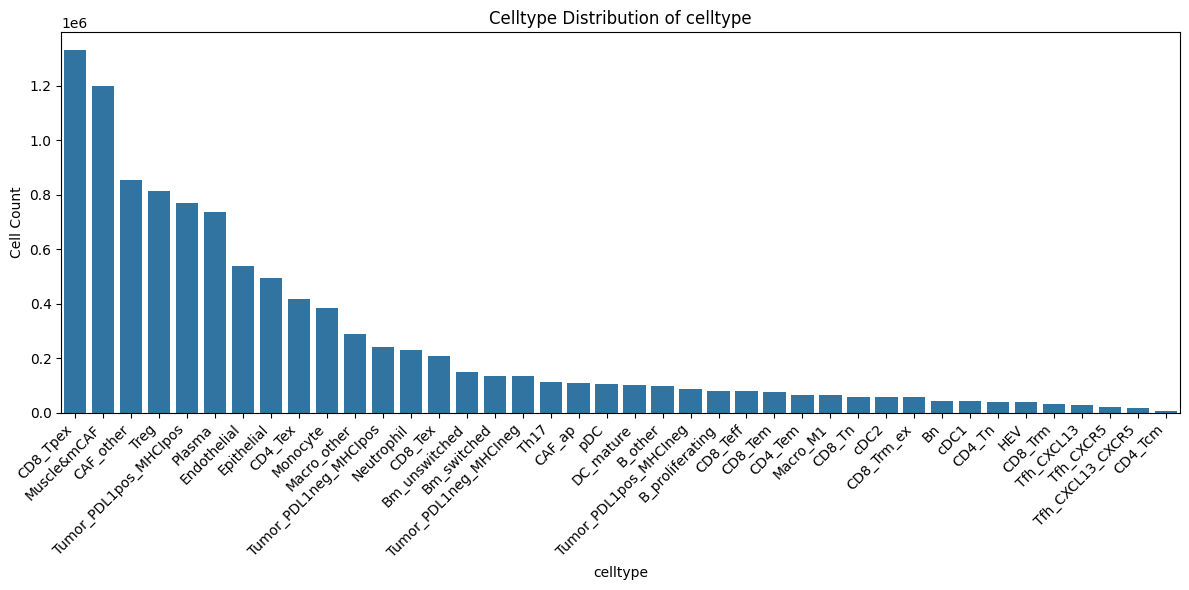

The number of cells in celltype_level1: 10365126
The distribution of celltype_level1: celltype_level1
Stromal       2736176
CD8+T         1840623
CD4+T         1528471
Myeloid       1279134
B             1250217
Tumor         1234068
Epithelial     496437
Name: count, dtype: int64


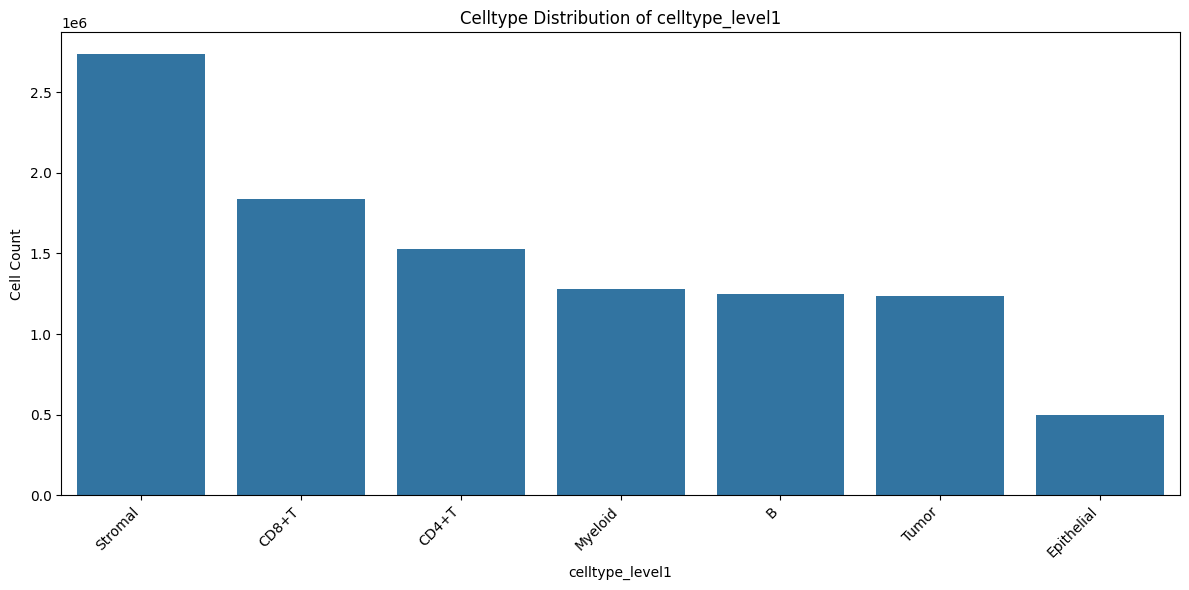

In [8]:
plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level1.pdf')

The number of cells in celltype: 80303
The distribution of celltype: celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 444
B_other                    426
Bm_switched                376
Bm_unswitched              354
cDC2                       294
CD4_Tem                    274
CAF_ap                     223
cDC1                       219
Th17                       200
CD8_Tn                     165
Tfh_CXCL13_CXCR5       

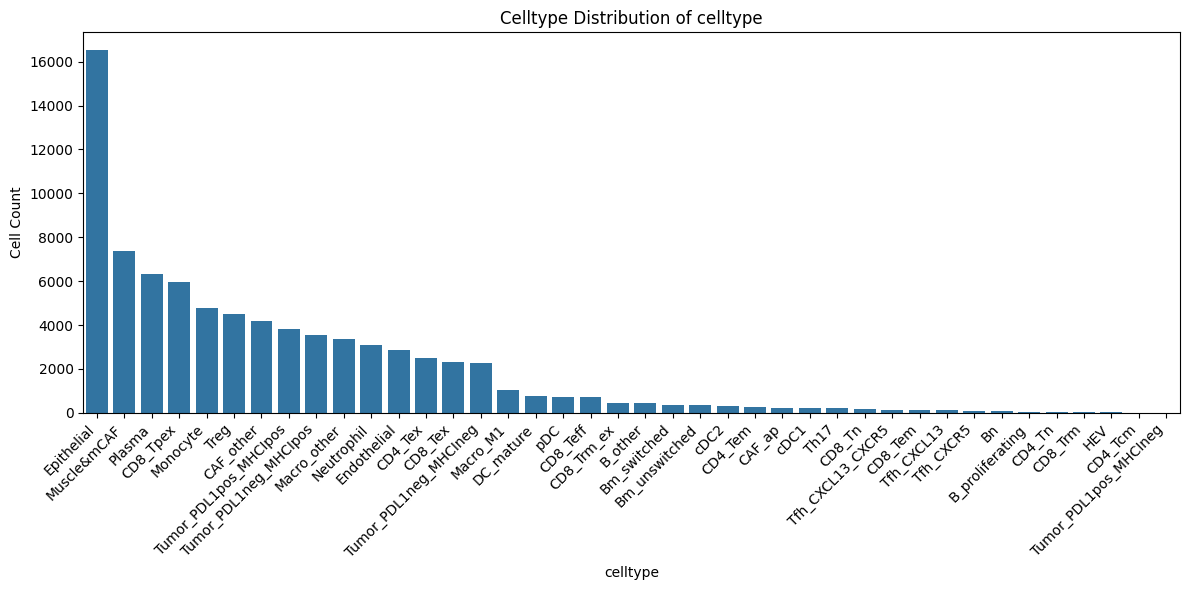

The number of cells in celltype_level1: 80303
The distribution of celltype_level1: celltype_level1
Epithelial    16508
Stromal       14692
Myeloid       14218
CD8+T          9815
Tumor          9591
CD4+T          7887
B              7592
Name: count, dtype: int64


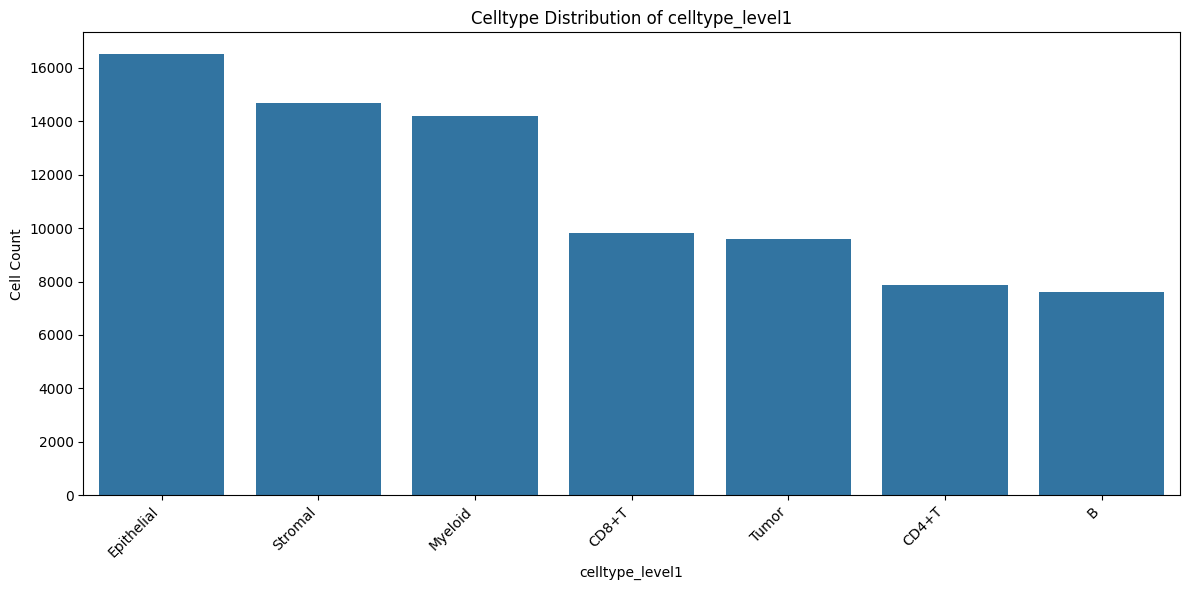

In [9]:
plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level2.pdf')

plot_celltype_distribution(celltype_NCRT_tumor1, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level1.pdf')

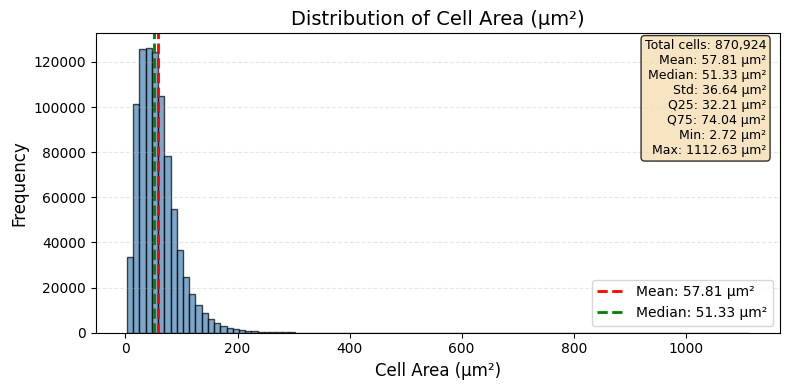


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 870,924
  Mean: 57.81 µm²
  Median: 51.33 µm²
  Standard deviation: 36.64 µm²
  Range: [2.72, 1112.63] µm²
  IQR: [32.21, 74.04] µm²


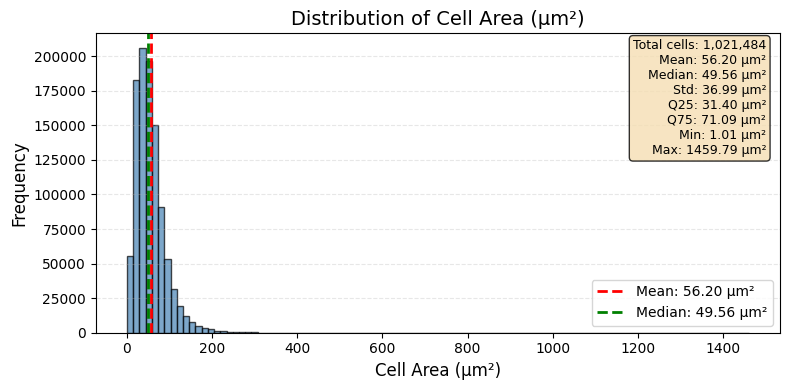


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,021,484
  Mean: 56.20 µm²
  Median: 49.56 µm²
  Standard deviation: 36.99 µm²
  Range: [1.01, 1459.79] µm²
  IQR: [31.40, 71.09] µm²


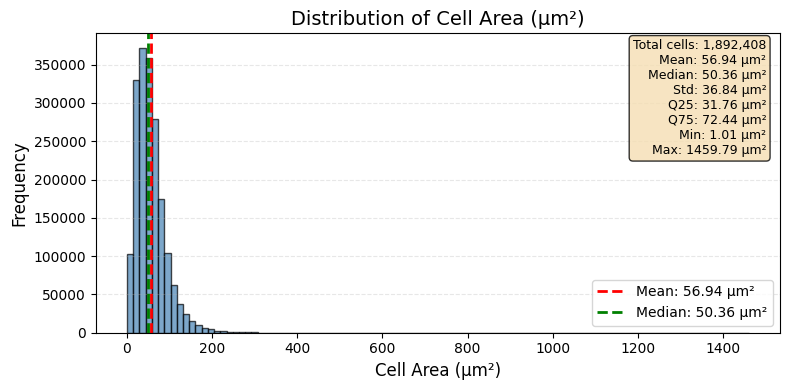


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,892,408
  Mean: 56.94 µm²
  Median: 50.36 µm²
  Standard deviation: 36.84 µm²
  Range: [1.01, 1459.79] µm²
  IQR: [31.76, 72.44] µm²


In [10]:
plot_cell_area_histogram(celltype_coords_df1, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_1_14.pdf')
plot_cell_area_histogram(celltype_coords_df2, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist_15_28.pdf')
plot_cell_area_histogram(celltype_coords_df, 
                        save_path=None)
                        # save_path=f'{therapy_data}/{save_result}/cellarea_dist.pdf')

In [11]:
## celltype_NCRT_tumor1
celltype_NCRT_tumor1 = get_celltype_coords(celltype_anno_df, celltype_coords_df, value='NCRT_tumor1', parent_value='tumor1')
celltype_NCRT_tumor1.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (1892408, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor15'
 'tumor16' 'tumor17' 'tumor18' 'tumor19' 'tumor20' 'tumor21' 'tumor22'
 'tumor23' 'tumor24' 'tumor25' 'tumor26' 'tumor28' 'tumor27']
After filtering for 'tumor1' - ncrt_anno_df1_tumor1 shape: (82805, 58)
Number of cells in tumor1: 82805

Shape of celltype_NCRT_tumor1 before merging: (80303, 5)
Shape of ncrt_anno_df1_tumor1: (82805, 58)
Shape of celltype_NCRT_tumor1 after merging: (80303, 7)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 80303 / 80303 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635


### Visualization CODEX tumorX

Number of valid data points: 80303
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

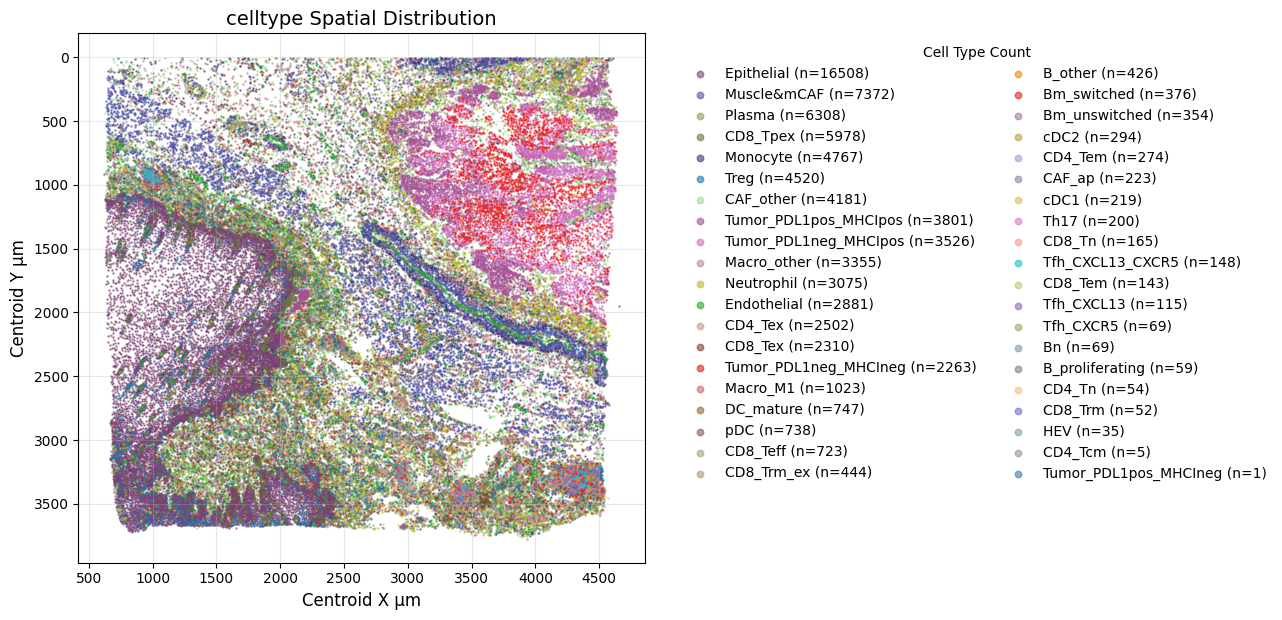

In [12]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level2.jpg')

Number of valid data points: 80303
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level1 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

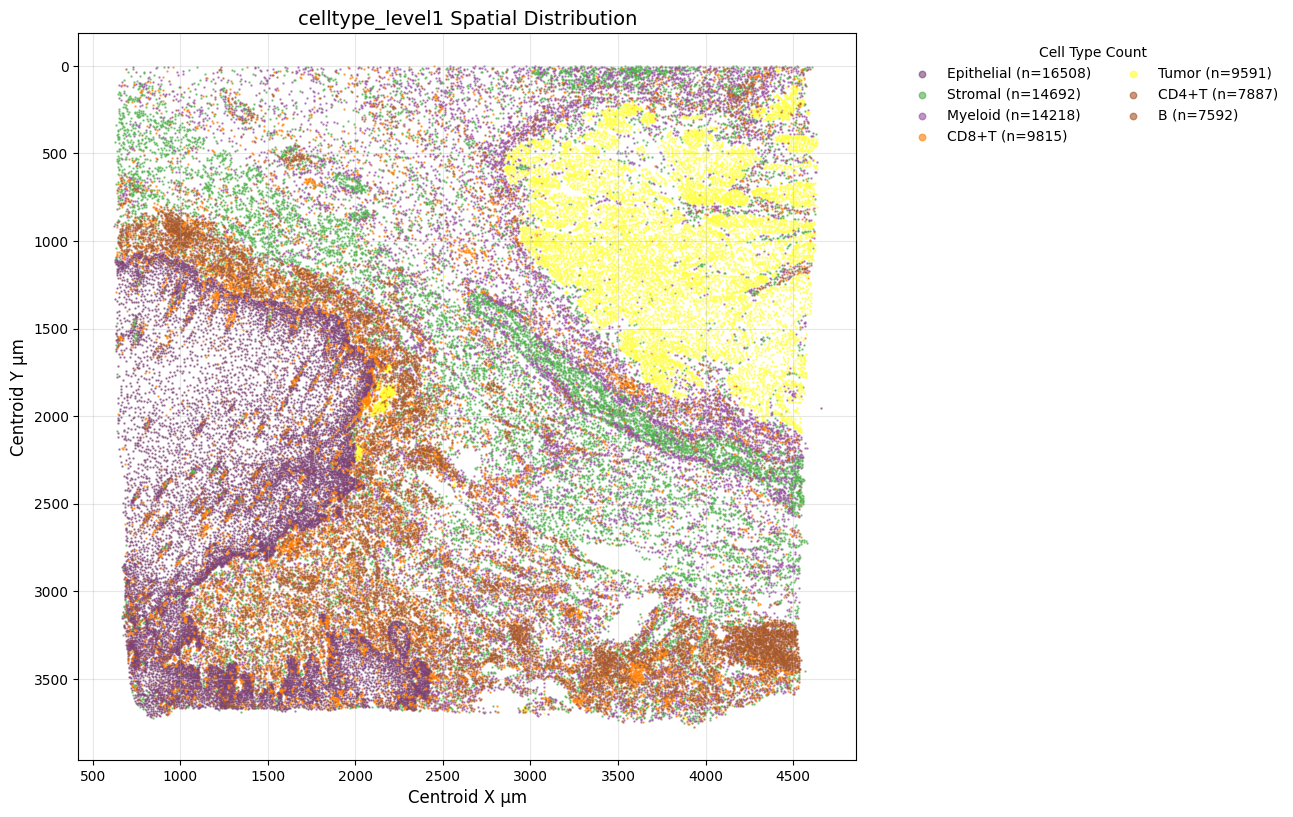

In [13]:
plot_celltype_spatial_distribution(celltype_NCRT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level1',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

In [14]:
# ## celltype_NCRT_tumor5
# celltype_NCRT_tumor5 = get_celltype_coords(celltype_anno_df, celltype_coords_df1, value='NCRT_tumor5', parent_value='tumor5')
# # celltype_NCRT_tumor5.head()
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level2.jpg')
# plot_celltype_spatial_distribution(celltype_NCRT_tumor5,
#                                    x_col='Centroid X µm', y_col='Centroid Y µm',
#                                    celltype_col='celltype_level1',
#                                    figsize=(12, 10), alpha=0.6,s=0.6,
#                                    # format='jpg', save_path=None)  
#                                     format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level1.jpg')

### Alignment: Coordinates transform: PCF -> HE

- Transformation matrix exported from QuPath: [up: HE; down: PCF]
- Here, In QuPath, NCRT PCF.qptiff is the reference (front) and NCRT HE.qptiff is the target (back)
- QuPath shows HE->PCF, we need PCF->HE (INVERT the matrix)

In [29]:
## Load images
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}'
he_cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords.csv'
he_cell_coords4ViT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT.csv'

he_cell_coords_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
he_cell_coords4ViT_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT_tumor1.csv'

In [25]:
####################################
# celltype_pixel_NCRT
####################################
celltype_pixel_NCRT = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='3', 
                                            value='NCRT', parent_value=None,
                                            # save_path=he_cell_coords_path, save_path4ViT=he_cell_coords4ViT_path)
                                            save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83752773e-01 -7.72653508e-03 -5.46157726e+03]
 [ 7.72653508e-03  9.83752773e-01 -2.10318222e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4427°
  Translation: X=-5461.6, Y=-2103.2

Inverted matrix (PCF -> HE):
[[ 1.01645286e+00  7.98336622e-03  5.56822628e+03]
 [-7.98336622e-03  1.01645286e+00  2.09418381e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.4574°
  Translation: X=5568.2, Y=2094.2
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 47040
height read from server.json: 70560
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Dont filtering - parent value: 'Parent' column
Available columns: ['Image', 'CellID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2']
Shape of cellty

In [30]:
print("Cell numbers with NCRT:", celltype_pixel_NCRT.shape[0])
celltype_pixel_NCRT.head()

Cell numbers with NCRT: 1746948


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


In [35]:
####################################
# celltype_pixel_NCRT
####################################
celltype_pixel_NCRT_tumor1 = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='3', 
                                            value='NCRT', parent_value='tumor1',
                                            # save_path=he_cell_coords_tumor1_path, save_path4ViT=he_cell_coords4ViT_tumor1_path)
                                            save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83752773e-01 -7.72653508e-03 -5.46157726e+03]
 [ 7.72653508e-03  9.83752773e-01 -2.10318222e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4427°
  Translation: X=-5461.6, Y=-2103.2

Inverted matrix (PCF -> HE):
[[ 1.01645286e+00  7.98336622e-03  5.56822628e+03]
 [-7.98336622e-03  1.01645286e+00  2.09418381e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.4574°
  Translation: X=5568.2, Y=2094.2
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 47040
height read from server.json: 70560
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (1892408, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor

In [36]:
print("Cell numbers with NCRT tumor1:", celltype_pixel_NCRT_tumor1.shape[0])
celltype_pixel_NCRT_tumor1.head()

Cell numbers with NCRT tumor1: 80303


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


## HIPT

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5 -->

In [27]:
## Load celltype_pixel_NCRT
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords4ViT.csv')
celltype_pixel_NCRT.head()

,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords4ViT_tumor1.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/ \
#    --scale 0.5  

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords4ViT.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_all/ImgEmbeddings_all/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_all/ImgEmbeddings_all/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_all/ImgEmbeddings_all/ \
#    --scale 0.5  

[2026-03-18 19:49:09] INFO - tissue_position number: 80303
[2026-03-18 19:49:09] INFO - tissue_position range: 14916.687368292329 9578.480430557478
[2026-03-18 19:49:09] INFO - Loading image at original resolution (no scaling)
[2026-03-18 19:49:09] INFO - image_width, image_height: 47040, 70560
[2026-03-18 19:49:39] INFO - Image segmentation time: 29.98 seconds
[2026-03-18 19:49:39] INFO - Method: HIPT
[2026-03-18 19:56:19] INFO - Feature extraction time: 399.56 seconds

## Cell Type Classification Model

In [2]:
# Load required libraries for machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score, 
                            precision_recall_fscore_support)
import seaborn as sns
import torch
from pathlib import Path
from tqdm import tqdm
import re
import os
import numpy as np
import pandas as pd

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
def load_cell_pixcoords(cell_coords_path):
    print("Loading celltype Ground Truth ...")
    if not os.path.exists(cell_coords_path):
        print(f"  File not found: {cell_coords_path}")
        return None

    celltype_pixel_NCRT_tumor1 = pd.read_csv(cell_coords_path)
    print(f"  Loaded {len(celltype_pixel_NCRT_tumor1)} cells")
    # print(f"  Columns: {celltype_pixel_NCRT_tumor1.columns.tolist()}")
    print(f"  Cell types: {celltype_pixel_NCRT_tumor1['celltype'].nunique()} unique types")
    # print(f"  Cell type distribution:\n{celltype_pixel_NCRT_tumor1['celltype'].value_counts()}")
    
    print("="*60 + "\n")
    return celltype_pixel_NCRT_tumor1

## Load celltype data (ground truth Y) - celltype_pixel_NCRT_tumor1
# cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
# celltype_pixel_NCRT_tumor1 = load_cell_pixcoords(cell_coords_path)

In [4]:
from pathlib import Path  
def load_hist_embeddings(embedding_dir):
    print("Loading HIPT embeddings from .pth files...")
    pth_files = list(embedding_dir.glob('*.pth'))
    # print(f"  Found {len(pth_files)} .pth files")

    embeddings_dict, failed_files = load_embeddings(pth_files)
    print(f"  Successfully loaded {len(embeddings_dict)} embeddings")

    if len(failed_files) > 5:
        print(f"  ... and {len(failed_files) - 5} more files failed to load")
    if len(failed_files) > 0:
        print(f"  Total failed: {len(failed_files)} files")
    if len(embeddings_dict) > 0:
        sample_emb = list(embeddings_dict.values())[0]
        print(f"  Embedding dimension: {sample_emb.shape}")
        # print(f"  Sample embedding dtype: {sample_emb.dtype}")
    else:
        print("  ERROR: No embeddings loaded! Please check the .pth files.")

    print("="*60 + "\n")
    return embeddings_dict

## Load HIPT embeddings from .pth files (Input X)
# hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16')
# embeddings_dict = load_hist_embeddings(hist_embedding_dir)

In [ ]:
# Match embeddings with celltype data by coordinates
# Check if matched data already exists
# os.remove(matched_features_path)    # remove matched_features_tumor1.npz


# import pickle
# matched_data_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/matched_data_tumor1.pkl'


from pathlib import Path
def match_hist2cell_matrix(cell_coords_path, hist_embedding_dir, 
                           matched_features_path, coord_cols=('X_pix_HE', 'Y_pix_HE')):
    ## Load celltype data (ground truth Y) - celltype_pixel_NCRT_tumor1
    celltype_pixel_NCRT_tumor1 = load_cell_pixcoords(cell_coords_path)        
    ## Load HIPT embeddings from .pth files (Input X)
    embeddings_dict = load_hist_embeddings(hist_embedding_dir)
    ## Load matched embeddings (returns X, y, and optionally X_coords)
    result = prepare_matched_embeddings(celltype_pixel_NCRT_tumor1, embeddings_dict, 
                                        matched_features_path, coord_cols=coord_cols)

    if len(result) == 3:
        X, y, X_coords_matched = result
        if X_coords_matched is not None:
            print(f"  ✓ Coordinates loaded: {X_coords_matched.shape}")
    else:
        X, y = result
        X_coords_matched = None
        print(f"  ⚠ Coordinates not available (old format)")
    
    return X, y, X_coords_matched


cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16')
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/matched_features_tumor1.npz'

X, y, X_coords_matched = match_hist2cell_matrix(cell_coords_path, hist_embedding_dir, 
                                                matched_features_path, coord_cols=('X_pix_HE', 'Y_pix_HE'))

Loading celltype Ground Truth ...
  Loaded 80303 cells
  Cell types: 40 unique types

Loading HIPT embeddings from .pth files...
  Loading embeddings...


Loading .pth files: 100%|██████████| 80303/80303 [00:08<00:00, 9143.35it/s]


  Successfully loaded 80303 embeddings
  Embedding dimension: (384,)

Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz
  X shape: (80303, 384)
  y shape: (80303,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (80303, 2)


### Train and test datasets 

In [6]:
# Train/Test split (70% / 30%)
# Fix: stratified split fails when some classes appear only once.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Filter out classes with <2 samples
unique_labels, counts = np.unique(y_encoded, return_counts=True)
keep_labels = unique_labels[counts >= 2]
mask = np.isin(y_encoded, keep_labels)

X_f = X[mask]
y_f = y[mask]
y_encoded_f = y_encoded[mask]

# If only 1 class remains, stratify must be disabled
strat = y_encoded_f if len(keep_labels) > 1 else None

X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X_f, y_f, y_encoded_f,
    test_size=0.3,
    random_state=42,
    stratify=strat,
)

print(f"\nTrain/Test split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Feature dimension: {X_train.shape[1]}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("  Features standardized")


Train/Test split:
  Training set: 56211 samples
  Test set: 24091 samples
  Feature dimension: 384
  Features standardized


## MLP classifier

In [7]:
# Check GPU availability
import torch
import torch.nn as nn

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Warning: CUDA not available, will use CPU (slower)")

CUDA available: False


In [8]:
## Create PyTorch Dataset and DataLoader
train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    X_train_scaled, y_train_encoded, X_test_scaled, y_test_encoded
)

Train dataset size: 56211
Val dataset size: 24091
Batch size: 256
Feature dimension: 384


In [9]:
# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train_encoded))  # Use actual number of classes in training data

print(f"Model configuration:")
print(f"  Input dimension: {input_dim}")
print(f"  Number of classes: {num_classes}")
print(f"  Class names: {class_names}")

# Use improved model with larger capacity
model = ImprovedMLPClassifier(
    input_dim=input_dim, 
    num_classes=num_classes,  # Use actual number of classes
    hidden_dims=[1024, 512, 256],  # Larger capacity
    dropout=0.2  # Reduced dropout
).to(device)

print(f"Model initialized on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Calculate class weights for imbalanced data
# Use only classes that appear in training data
unique_classes = np.unique(y_train_encoded)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=y_train_encoded
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Class weights computed for {len(unique_classes)} classes")
print(f"  Weight range: min={class_weights.min():.3f}, max={class_weights.max():.3f}")
print(f"  Weight tensor shape: {class_weights_tensor.shape}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer with better learning rate
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,  # Higher initial learning rate
    weight_decay=5e-5,  # Reduced weight decay
    betas=(0.9, 0.999),
    eps=1e-8
)

# Learning rate scheduler with warmup
from torch.optim.lr_scheduler import OneCycleLR

scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=50,  # More epochs
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos'
)

# Mixed precision training (AMP)
# Note: Using 'amp_scaler' to avoid conflict with 'scaler' (StandardScaler) from Cell 52
amp_scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
print(f"Mixed precision training: {amp_scaler is not None}")
print(f"Using OneCycleLR scheduler with warmup")

Model configuration:
  Input dimension: 384
  Number of classes: 39
  Class names: ['B_other' 'B_proliferating' 'Bm_switched' 'Bm_unswitched' 'Bn' 'CAF_ap'
 'CAF_other' 'CD4_Tcm' 'CD4_Tem' 'CD4_Tex' 'CD4_Tn' 'CD8_Teff' 'CD8_Tem'
 'CD8_Tex' 'CD8_Tn' 'CD8_Tpex' 'CD8_Trm' 'CD8_Trm_ex' 'DC_mature'
 'Endothelial' 'Epithelial' 'HEV' 'Macro_M1' 'Macro_other' 'Monocyte'
 'Muscle&mCAF' 'Neutrophil' 'Plasma' 'Tfh_CXCL13' 'Tfh_CXCL13_CXCR5'
 'Tfh_CXCR5' 'Th17' 'Treg' 'Tumor_PDL1neg_MHCIneg' 'Tumor_PDL1neg_MHCIpos'
 'Tumor_PDL1pos_MHCIneg' 'Tumor_PDL1pos_MHCIpos' 'cDC1' 'cDC2' 'pDC']
Model initialized on cpu
Model parameters: 1,063,975
Class weights computed for 39 classes
  Weight range: min=0.125, max=360.327
  Weight tensor shape: torch.Size([39])
Mixed precision training: False
Using OneCycleLR scheduler with warmup


In [10]:
## Train 
best_weighted_f1, best_macro_f1, best_epoch = train_model(
    model, train_loader, val_loader, optimizer, scheduler, criterion,
    evaluate, device, amp_scaler, path, therapy_data, patience=10, max_epochs=50
)

Starting training with improved model...


IndexError: Target 39 is out of bounds.

In [ ]:
# Load best model and evaluate on test set
print("Loading best model and evaluating on test set...")

model.load_state_dict(torch.load(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"))
test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate(model, val_loader, device)

print(f"\nFinal Test Set Performance:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Macro F1-score: {test_macro_f1:.4f}")
print(f"  Weighted F1-score: {test_weighted_f1:.4f}")

# Get actual class labels that appear in the test set
unique_labels = np.unique(np.concatenate([test_labels, test_preds]))
actual_class_names = [class_names[i] for i in unique_labels]

# Detailed classification report (only for classes that appear in test set)
print(f"\nDetailed Classification Report:")
print(f"  Number of classes in test set: {len(unique_labels)}")
print(classification_report(test_labels, test_preds, labels=unique_labels, target_names=actual_class_names, zero_division=0))

Loading best model and evaluating on test set...

Final Test Set Performance:
  Accuracy: 0.3313
  Macro F1-score: 0.1895
  Weighted F1-score: 0.3304

Detailed Classification Report:
  Number of classes in test set: 20
                       precision    recall  f1-score   support

            CAF_other       0.17      0.14      0.15      1254
              CD4_Tex       0.08      0.10      0.09       751
             CD8_Teff       0.05      0.17      0.07       217
              CD8_Tex       0.07      0.10      0.08       693
             CD8_Tpex       0.16      0.07      0.09      1793
           CD8_Trm_ex       0.01      0.02      0.02       133
            DC_mature       0.03      0.08      0.05       224
          Endothelial       0.15      0.22      0.18       864
           Epithelial       0.79      0.80      0.80      4953
             Macro_M1       0.04      0.08      0.05       307
          Macro_other       0.10      0.12      0.11      1007
             Monocyte   

Computing confusion matrix...


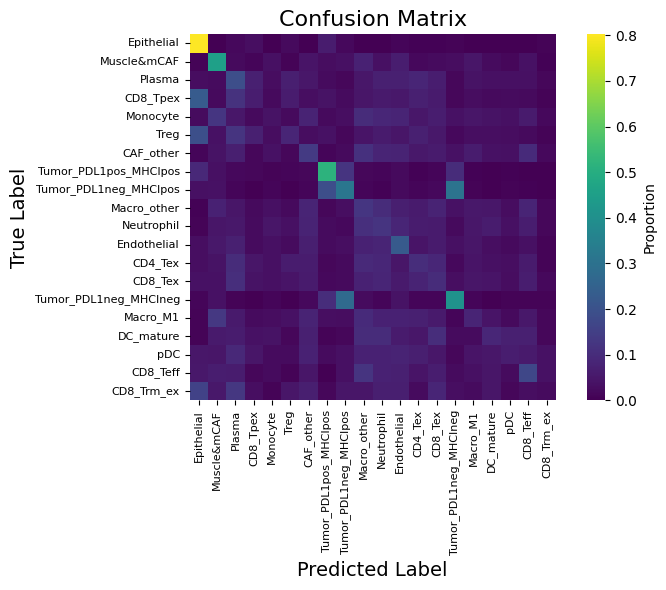

In [ ]:
plot_confusion_matrix(test_labels, test_preds, class_names, normalize=True,
    # save_path="confusion_matrix_main.pdf"
)

Visualizing per-class performance...
  ✓ Computed metrics for 20 classes


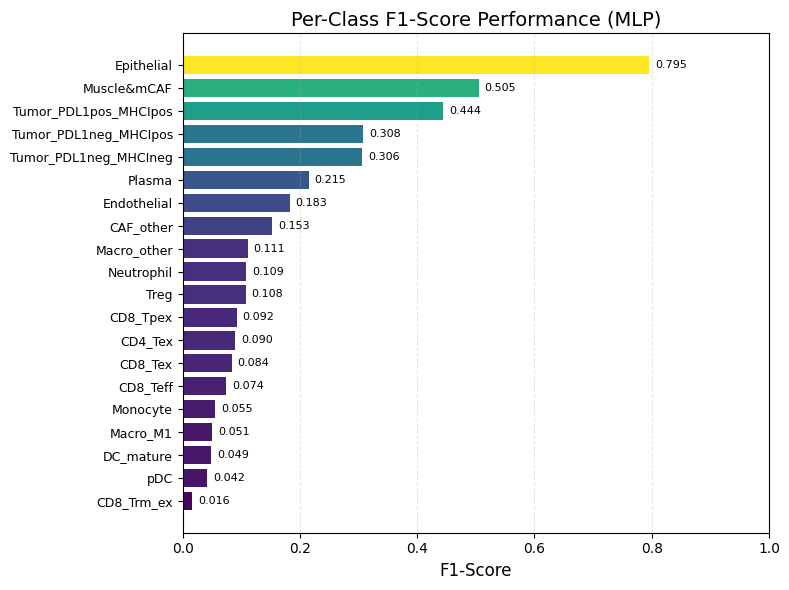


Model Summary:
  Device: cpu
  Training samples: 53915
  Test samples: 23107
  Total classes (before filtering): 20
  Actual classes in test set: 20
  Feature dimension: 384
  Model parameters: 1,059,092
  Best epoch: 47
  Test Accuracy: 0.3313
  Test Macro F1: 0.1895
  Test Weighted F1: 0.3304


In [ ]:
metrics_df = plot_per_class_f1(
    test_labels,
    test_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=test_acc,
    test_macro_f1=test_macro_f1,
    test_weighted_f1=test_weighted_f1,
    model_name="MLP",
    # save_path="per_class_f1.pdf"
)


Loading best model and evaluating on all data (in original order)...
  Using original filtered X and y...


  Total samples: 77022

Final Performance on All Data:
  Accuracy: 0.4687
  Macro F1-score: 0.3882
  Weighted F1-score: 0.4588

Detailed Classification Report:
  Number of classes: 20
                       precision    recall  f1-score   support

            CAF_other       0.28      0.20      0.23      4181
              CD4_Tex       0.29      0.38      0.33      2502
             CD8_Teff       0.19      0.71      0.30       723
              CD8_Tex       0.26      0.39      0.32      2310
             CD8_Tpex       0.35      0.14      0.20      5978
           CD8_Trm_ex       0.37      0.69      0.48       444
            DC_mature       0.25      0.66      0.37       747
          Endothelial       0.33      0.48      0.39      2881
           Epithelial       0.82      0.82      0.82     16508
             Macro_M1       0.26      0.62      0.37      1023
          Macro_other       0.23      0.28      0.25      3355
             Monocyte       0.36      0.13      0.19      4

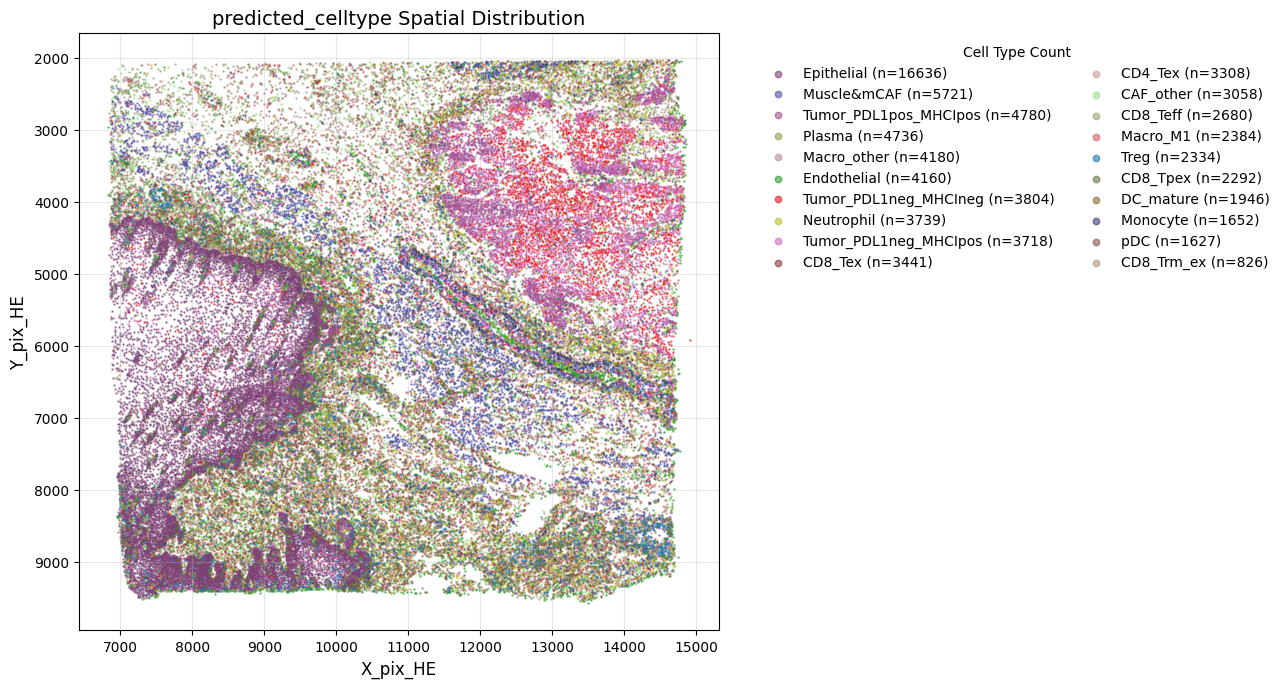


Plotting spatial distribution of TRUE cell types (for comparison)...


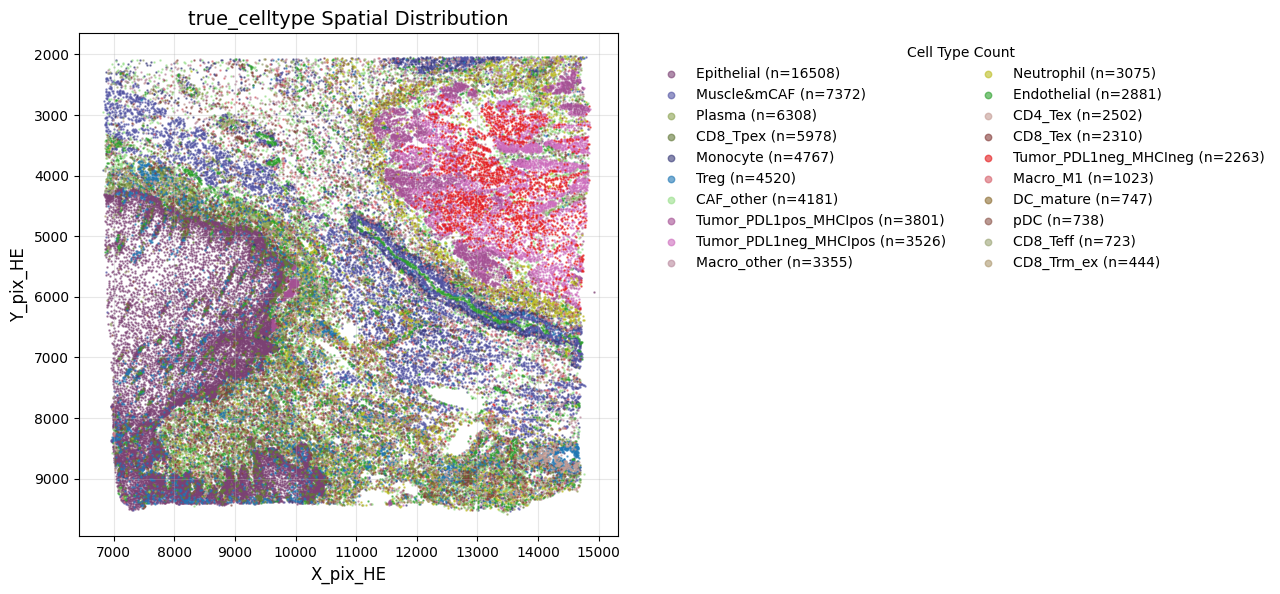

In [ ]:
# Load best model and prepare paths
print("Loading best model and evaluating on all data (in original order)...")
model.load_state_dict(torch.load(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"))
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1.npz'

# Evaluate on all data and plot spatial distribution
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_path,
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if 'val_loader' in globals() else None,
    X=X if 'X' in globals() else None,
    y=y if 'y' in globals() else None,
    y_encoded=y_encoded if 'y_encoded' in globals() else None,
    X_train=X_train if 'X_train' in globals() else None,
    X_train_scaled=X_train_scaled if 'X_train_scaled' in globals() else None,
    X_test_scaled=X_test_scaled if 'X_test_scaled' in globals() else None,
    y_train_encoded=y_train_encoded if 'y_train_encoded' in globals() else None,
    y_test_encoded=y_test_encoded if 'y_test_encoded' in globals() else None,
    min_samples_per_class=min_samples_per_class if 'min_samples_per_class' in globals() else 29,
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if 'celltype_pixel_NCRT_tumor1' in globals() else None
)

## HE-feature validation

```python
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
export_data = 'export'
```

In [ ]:
## Load stardist coords from YuLu - no duplicates
star_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/NCTR_Float_prob0.01_nms_0.3.csv')
print(star_coords.shape)
star_coords.head() 

(2028114, 3)


,centroid_x,centroid_y,probability
0,2310.191299,53.845082,0.654038
1,6863.988266,3320.483284,0.884281
2,7168.098045,1736.226154,0.878382
3,7189.928642,1536.107811,0.877665
4,7227.680878,1686.196735,0.875756


In [ ]:
## filter ROI using ROI coords from Qupath annotation by myself
roi_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}/ROI_Corners.csv')
print(roi_coords.shape)
roi_coords.head()

(28, 9)


,Name,TopLeft_X,TopLeft_Y,TopRight_X,TopRight_Y,BottomRight_X,BottomRight_Y,BottomLeft_X,BottomLeft_Y
0,tumor27,24361.0,58935.0,32781.0,58935.0,32781.0,67524.0,24361.0,67524.0
1,tumor10,15298.0,20327.0,23887.0,20327.0,23887.0,29136.0,15298.0,29136.0
2,tumor24,33103.0,49617.0,41793.0,49617.0,41793.0,58037.0,33103.0,58037.0
3,tumor22,15654.0,49719.0,24209.0,49719.0,24209.0,58122.0,15654.0,58122.0
4,tumor4,33018.0,1184.0,41607.0,1184.0,41607.0,9586.0,33018.0,9586.0


In [ ]:
## Match StarCoords to ROI
star_coords_out, star_coords_in_roi, roi_cell_counts = match_StarCoords2ROI(
    star_coords, roi_coords, therapy_data="NCRT"
)

Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

In [ ]:
## Load GT and CellPixCoords
celltype_anno_df = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv')
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCRT_tumor3', 'NCRT_tumor6', 'NCRT_tumor10', 'NCRT_tumor15', 'NCRT_tumor25', 'NCRT_tumor28']


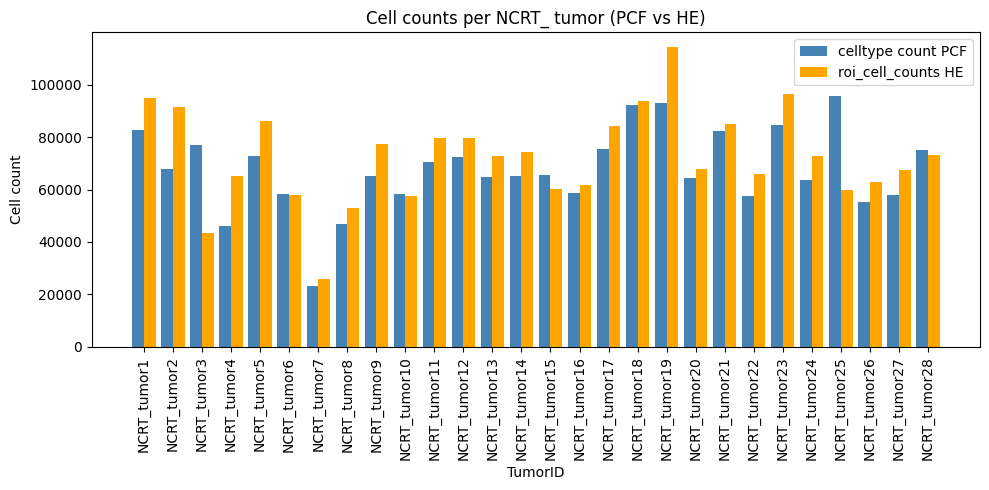

,TumorID,celltype_count,cell_count,tumor_num
0,NCRT_tumor1,82805,94963,1
1,NCRT_tumor2,67990,91422,2
2,NCRT_tumor3,77130,43568,3
3,NCRT_tumor4,46044,65337,4
4,NCRT_tumor5,72694,86115,5


In [ ]:
merged = plot_WSI_counts(celltype, roi_cell_counts, prefix='NCRT_')
merged.head()

In [ ]:
## model_star: per-class F1 for level2 + level1
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# Resolve level2 preds/labels
# -----------------------------
if 'val_preds_star' in globals() and 'val_labels_star' in globals():
    star_preds_l2 = np.asarray(val_preds_star)
    star_labels_l2 = np.asarray(val_labels_star)
elif 'all_preds_star' in globals() and 'all_labels_star' in globals():
    star_preds_l2 = np.asarray(all_preds_star)
    star_labels_l2 = np.asarray(all_labels_star)
elif 'all_preds' in globals() and 'all_labels' in globals() and 'model_star' in globals():
    # Fallback: if the immediately previous star-eval cell used all_preds/all_labels naming
    star_preds_l2 = np.asarray(all_preds)
    star_labels_l2 = np.asarray(all_labels)
else:
    raise ValueError("Cannot find model_star level2 preds/labels. Expected val_preds_star/val_labels_star or all_preds_star/all_labels_star.")

if 'class_names_star' in globals() and class_names_star is not None:
    star_class_names_l2 = class_names_star
elif 'class_names' in globals() and class_names is not None:
    star_class_names_l2 = class_names
else:
    raise ValueError("class_names_star (or class_names) is required for level2 plotting.")

# Optional summary metrics for the chart footer
star_l2_acc = accuracy_score(star_labels_l2, star_preds_l2)
star_l2_macro_f1 = f1_score(star_labels_l2, star_preds_l2, average='macro', zero_division=0)
star_l2_weighted_f1 = f1_score(star_labels_l2, star_preds_l2, average='weighted', zero_division=0)

metrics_df_star_level2 = plot_per_class_f1(
    star_labels_l2,
    star_preds_l2,
    star_class_names_l2,
    model=model_star if 'model_star' in globals() else model,
    device=device,
    train_dataset=train_dataset if 'train_dataset' in globals() else None,
    val_dataset=val_dataset if 'val_dataset' in globals() else None,
    input_dim=input_dim if 'input_dim' in globals() else None,
    best_epoch=best_epoch if 'best_epoch' in globals() else None,
    test_acc=star_l2_acc,
    test_macro_f1=star_l2_macro_f1,
    test_weighted_f1=star_l2_weighted_f1,
    model_name='MLP-Star-Level2',
    save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_star_level2_hce.pdf',
)

# -----------------------------
# Level2 -> Level1 mapping
# -----------------------------
if 'class_names_level1' not in globals() or class_names_level1 is None:
    raise ValueError("class_names_level1 is required for level1 plotting.")
if 'y_encoded_f' not in globals() or 'y_level1_encoded_f' not in globals():
    raise ValueError("y_encoded_f and y_level1_encoded_f are required to build level2->level1 mapping.")

num_l2 = len(star_class_names_l2)
child_to_parent = np.full(num_l2, -1, dtype=np.int64)
for l2, l1 in zip(y_encoded_f, y_level1_encoded_f):
    l2i = int(l2)
    if 0 <= l2i < num_l2 and child_to_parent[l2i] == -1:
        child_to_parent[l2i] = int(l1)

missing = np.where(child_to_parent < 0)[0]
if len(missing) > 0:
    raise ValueError(f'Missing level1 mapping for level2 classes: {missing}')

star_preds_l1 = child_to_parent[star_preds_l2]

# True level1 labels priority: explicit vars -> map from l2 labels
if 'val_labels_level1_star' in globals():
    star_labels_l1 = np.asarray(val_labels_level1_star)
elif 'all_labels_level1_star' in globals():
    star_labels_l1 = np.asarray(all_labels_level1_star)
else:
    star_labels_l1 = child_to_parent[star_labels_l2]

star_l1_acc = accuracy_score(star_labels_l1, star_preds_l1)
star_l1_macro_f1 = f1_score(star_labels_l1, star_preds_l1, average='macro', zero_division=0)
star_l1_weighted_f1 = f1_score(star_labels_l1, star_preds_l1, average='weighted', zero_division=0)

metrics_df_star_level1 = plot_per_class_f1(
    star_labels_l1,
    star_preds_l1,
    class_names_level1,
    model=model_star if 'model_star' in globals() else model,
    device=device,
    train_dataset=train_dataset if 'train_dataset' in globals() else None,
    val_dataset=val_dataset if 'val_dataset' in globals() else None,
    input_dim=input_dim if 'input_dim' in globals() else None,
    best_epoch=best_epoch if 'best_epoch' in globals() else None,
    test_acc=star_l1_acc,
    test_macro_f1=star_l1_macro_f1,
    test_weighted_f1=star_l1_weighted_f1,
    model_name='MLP-Star-Level1',
    save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_star_level1_hce.pdf',
)

print('Saved model_star per-class F1 plots for level2 and level1.')